In [16]:
import numpy as np
import matplotlib.pyplot as plt


# ==================================================
# Signal functions
# ==================================================

def spatial_grid(L, Nx):
    return np.linspace(-L / 2, L / 2, Nx, endpoint=False)


def gaussian_thickness_profile(x, d0, h, sigma, x0=0):
    return d0 + h * np.exp(-((x - x0) ** 2) / (2 * sigma ** 2))


def phase_signal(d, n, lam):
    k = 2 * np.pi / lam
    return n * k * d


def phi_from_f(f):
    alpha = np.sum(f)

    phi = np.sqrt(f / alpha)

    phi = np.asarray(phi, dtype=complex)
    phi = phi / np.linalg.norm(phi)

    return phi, alpha


def plot_signal(x, f, n_qubits):
    plt.figure(figsize=(7, 4))

    plt.plot(x * 1e6, f)

    plt.xlabel("x (µm)")
    plt.ylabel("f(x) = n k d(x) (rad)")
    plt.title(f"Gaussian Phase Signal ({n_qubits} qubits)")

    plt.grid(True)
    plt.tight_layout()
    plt.show()

n_qubits: 7
Nx: 128
alpha: 63.998377844180254
psi shape: (128,)
psi norm: 1.0
min psi: 0.00034080790711798635
max psi: 0.17654286663549423


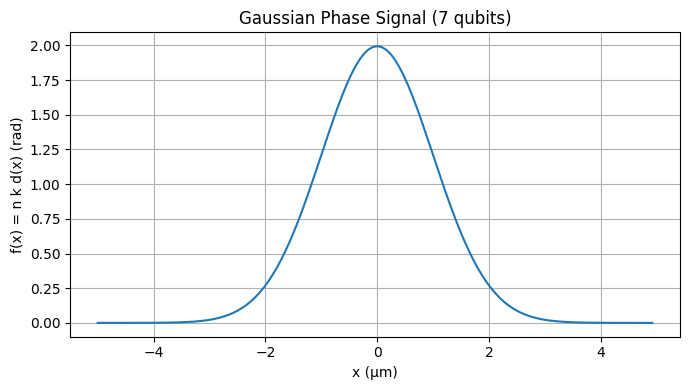

In [17]:
# ==================================================
# Parameters
# ==================================================

T = 10e-6

lam = 630e-9
n_refr = 1.0

d0 = 0.0
h = 200e-9
sigma = 1e-6
x0 = 0.0


# ==================================================
# Build psi for one chosen qubit number
# ==================================================

n_qubits = 7
Nx = 2 ** n_qubits

print("n_qubits:", n_qubits)
print("Nx:", Nx)

x = spatial_grid(T, Nx)

d = gaussian_thickness_profile(
    x=x,
    d0=d0,
    h=h,
    sigma=sigma,
    x0=x0
)

f = phase_signal(
    d=d,
    n=n_refr,
    lam=lam
)

psi, alpha = phi_from_f(f)

print("alpha:", alpha)
print("psi shape:", psi.shape)
print("psi norm:", np.linalg.norm(psi))
print("min psi:", np.min(np.abs(psi)))
print("max psi:", np.max(np.abs(psi)))

plot_signal(x, f, n_qubits)

In [18]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import StatePreparation
from qiskit.quantum_info import Statevector


# ==================================================
# Assume psi already exists
# ==================================================

psi = np.asarray(psi, dtype=complex)
psi = psi / np.linalg.norm(psi)

n_qubits = int(np.log2(len(psi)))

print("n_qubits:", n_qubits)
print("len(psi):", len(psi))
print("norm(psi):", np.linalg.norm(psi))


# ==================================================
# Target state
# ==================================================

target_state = Statevector(psi)

zero_state = Statevector.from_label("0" * n_qubits)

print("Target state dimension:", target_state.dim)
print("Zero state dimension:", zero_state.dim)


# ==================================================
# Build normal Qiskit StatePreparation circuit
# ==================================================
# This is:
#
#     U_prep |0> = |psi>
#
# No MPS initializer here.

qc_prepare = QuantumCircuit(n_qubits)

qc_prepare.append(
    StatePreparation(psi),
    range(n_qubits)
)

print("\nRaw preparation circuit:")
print(qc_prepare)


# ==================================================
# Disentangler
# ==================================================
# Since:
#
#     U_prep |0> = |psi>
#
# therefore:
#
#     U_prep dagger |psi> = |0>
#
# So this is your disentangler.

qc_disentangler = qc_prepare.inverse()

print("\nRaw disentangler circuit:")
print(qc_disentangler)

n_qubits: 7
len(psi): 128
norm(psi): 1.0
Target state dimension: 128
Zero state dimension: 128

Raw preparation circuit:
     »
q_0: »
     »
q_1: »
     »
q_2: »
     »
q_3: »
     »
q_4: »
     »
q_5: »
     »
q_6: »
     »
«     ┌───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

In [19]:
# ==================================================
# Decompose preparation circuit into ordinary gates
# ==================================================

qc_prepare_decomposed = qc_prepare.decompose(reps=5)

qc_prepare_decomposed = transpile(
    qc_prepare_decomposed,
    basis_gates=["u", "cx"],
    optimization_level=0
)

print("\nDecomposed preparation circuit depth:", qc_prepare_decomposed.depth())
print("Decomposed preparation circuit size:", qc_prepare_decomposed.size())


# ==================================================
# Disentangler from decomposed preparation circuit
# ==================================================

qc_disentangler_decomposed = qc_prepare_decomposed.inverse()

print("\nDisentangler depth:", qc_disentangler_decomposed.depth())
print("Disentangler size:", qc_disentangler_decomposed.size())


Decomposed preparation circuit depth: 241
Decomposed preparation circuit size: 247

Disentangler depth: 241
Disentangler size: 247


In [20]:
def analyze_disentangler_layers(
    qc_disentangler_decomposed,
    target_psi,
    n_qubits,
    fidelity_threshold=0.99,
    weight_threshold=0.999
):
    """
    Start from target state |psi>.
    Apply disentangler layers one by one.

    We check:
        1. Fidelity with |000...0>
        2. Effective max bond dimension after each layer

    This follows:

        |psi> -- U1 --> -- U2 --> ... --> |0>
    """

    target_state = Statevector(target_psi)
    zero_state = Statevector.from_label("0" * n_qubits)

    partial_qc = QuantumCircuit(n_qubits)

    layers = []
    fidelities_to_zero = []
    max_bonds = []
    rank_profiles = []

    last_depth = 0

    reached_layer = None
    reached_fidelity = None
    reached_max_bond = None
    reached_rank_profile = None

    # --------------------------------------------------
    # Initial target-state effective bond dimension
    # --------------------------------------------------
    initial_max_D, initial_rank_profile, initial_singular_values = max_effective_bond_dimension(
        target_state.data,
        n_qubits,
        weight_threshold=weight_threshold
    )

    initial_fidelity_to_zero = fidelity(
        zero_state.data,
        target_state.data
    )

    print("\nInitial target state:")
    print("Fidelity with |0>:", initial_fidelity_to_zero)
    print("Initial effective max bond dimension:", initial_max_D)
    print("Initial effective rank profile:", initial_rank_profile)

    # Save initial point as layer 0
    layers.append(0)
    fidelities_to_zero.append(initial_fidelity_to_zero)
    max_bonds.append(initial_max_D)
    rank_profiles.append(initial_rank_profile)

    # --------------------------------------------------
    # Apply disentangler layers
    # --------------------------------------------------
    for inst in qc_disentangler_decomposed.data:

        qubit_indices = [
            qc_disentangler_decomposed.find_bit(q).index
            for q in inst.qubits
        ]

        clbit_indices = [
            qc_disentangler_decomposed.find_bit(c).index
            for c in inst.clbits
        ]

        partial_qc.append(
            inst.operation,
            qubit_indices,
            clbit_indices
        )

        current_depth = partial_qc.depth()

        if current_depth == last_depth:
            continue

        last_depth = current_depth

        # Apply partial disentangler to target state
        current_state = target_state.evolve(partial_qc).data

        # Fidelity with |000...0>
        F_zero = fidelity(
            zero_state.data,
            current_state
        )

        # Effective bond dimension of current partially-disentangled state
        max_D_eff, eff_rank_profile, singular_values = max_effective_bond_dimension(
            current_state,
            n_qubits,
            weight_threshold=weight_threshold
        )

        layers.append(current_depth)
        fidelities_to_zero.append(F_zero)
        max_bonds.append(max_D_eff)
        rank_profiles.append(eff_rank_profile)

        print(
            f"Layer {current_depth:4d} | "
            f"Fidelity to |0> = {F_zero:.8f} | "
            f"Effective max bond dimension = {max_D_eff:4d} | "
            f"Effective rank profile = {eff_rank_profile}"
        )

        if reached_layer is None and F_zero >= fidelity_threshold:
            reached_layer = current_depth
            reached_fidelity = F_zero
            reached_max_bond = max_D_eff
            reached_rank_profile = eff_rank_profile

            print("\nReached zero-state fidelity threshold!")
            print("Layer:", reached_layer)
            print("Fidelity to |0>:", reached_fidelity)
            print("Effective max bond dimension:", reached_max_bond)
            print("Effective rank profile:", reached_rank_profile)

            break

    return {
        "layers": np.array(layers),
        "fidelities_to_zero": np.array(fidelities_to_zero),
        "max_bonds": np.array(max_bonds),
        "rank_profiles": rank_profiles,
        "reached_layer": reached_layer,
        "reached_fidelity": reached_fidelity,
        "reached_max_bond": reached_max_bond,
        "reached_rank_profile": reached_rank_profile,
        "initial_max_bond": initial_max_D,
        "initial_rank_profile": initial_rank_profile,
    }

In [21]:
fidelity_threshold = 0.99
weight_threshold = 0.999

dis_result = analyze_disentangler_layers(
    qc_disentangler_decomposed=qc_disentangler_decomposed,
    target_psi=psi,
    n_qubits=n_qubits,
    fidelity_threshold=fidelity_threshold,
    weight_threshold=weight_threshold
)


Initial target state:
Fidelity with |0>: 1.1615002955414201e-07
Initial effective max bond dimension: 3
Initial effective rank profile: [np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(1)]
Layer    1 | Fidelity to |0> = 0.00000014 | Effective max bond dimension =    3 | Effective rank profile = [np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(1)]
Layer    2 | Fidelity to |0> = 0.00000014 | Effective max bond dimension =    3 | Effective rank profile = [np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(1)]
Layer    3 | Fidelity to |0> = 0.00000017 | Effective max bond dimension =    3 | Effective rank profile = [np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(1)]
Layer    4 | Fidelity to |0> = 0.00000017 | Effective max bond dimension =    3 | Effective rank profile = [np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(1)]
Layer    5 | Fidelity to |0> = 0.0000001

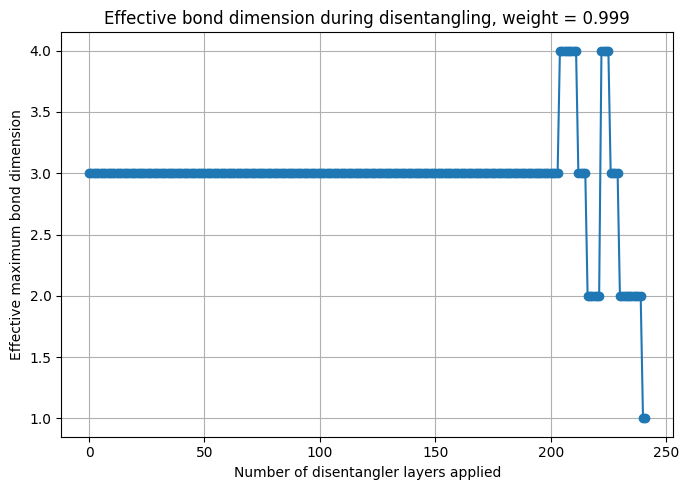

In [22]:
plt.figure(figsize=(7, 5))

plt.plot(
    dis_result["layers"],
    dis_result["max_bonds"],
    marker="o"
)

plt.xlabel("Number of disentangler layers applied")
plt.ylabel("Effective maximum bond dimension")
plt.title(f"Effective bond dimension during disentangling, weight = {weight_threshold}")

plt.grid(True)
plt.tight_layout()
plt.show()

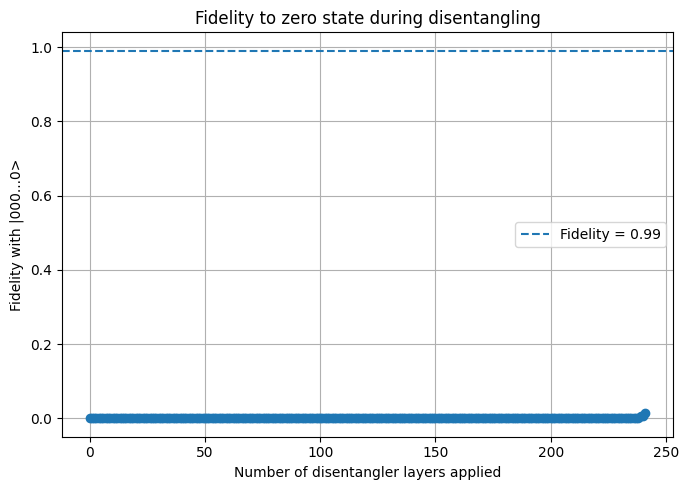

In [23]:
plt.figure(figsize=(7, 5))

plt.plot(
    dis_result["layers"],
    dis_result["fidelities_to_zero"],
    marker="o"
)

plt.axhline(
    fidelity_threshold,
    linestyle="--",
    label=f"Fidelity = {fidelity_threshold}"
)

plt.xlabel("Number of disentangler layers applied")
plt.ylabel("Fidelity with |000...0>")
plt.title("Fidelity to zero state during disentangling")

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

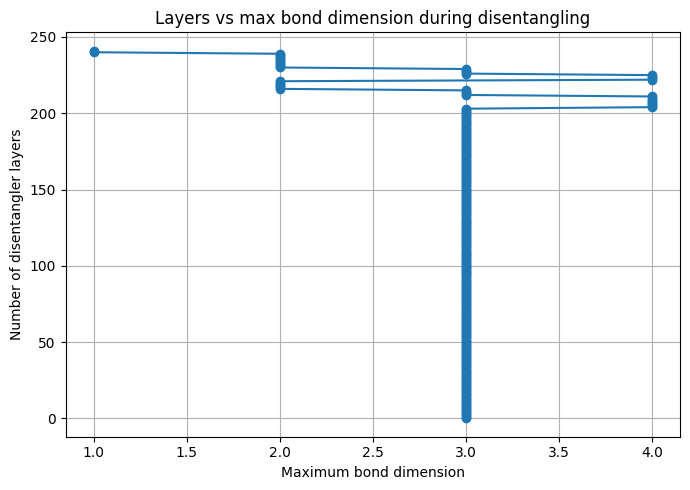

In [25]:
plt.figure(figsize=(7, 5))

plt.plot(
    dis_result["max_bonds"],
    dis_result["layers"],
    marker="o"
)

plt.xlabel("Maximum bond dimension")
plt.ylabel("Number of disentangler layers")
plt.title("Layers vs max bond dimension during disentangling")

plt.grid(True)
plt.tight_layout()
plt.show()